# Oppgave 1c)

In [2]:
# Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Lager funksjonen beskrevet i oppgaven

def RungeKutta_32(x_init, x_end, y_init, f, alpha, h_0, tol):
    n = 0                           # Teller antall steg som aksepteres
    n_total = 0                     # Teller antall steg som testes
    h_n = h_0                       # Steglengde ved steg n
    x_n = x_init                    # x-verdi ved steg n
    y_n = y_init                    # y-vektor ved steg n
    
    x_array = [x_n]                 # Liste til x-verdier for hvert steg
    y_matrix = [y_n]                # 2D-liste med y-vektor for hvert steg 
    step_array = []                 # Liste til steglengde for hvert steg


    k_1 = f(x_init, y_init)

    while (x_end - x_n) > 0:
        h_n = min(h_n, x_end - x_n)
        k_2 = f(x_n + (1/2)*h_n, y_n + (1/2)*h_n*k_1)
        k_3 = f(x_n + (3/4)*h_n, y_n + (3/4)*h_n*k_2)

        y_next = y_n + (1/9)*h_n*(2*k_1 + 3*k_2 + 4*k_3)                # Midlertig oppdatering av y
        x_next = x_n + h_n                                              # Oppdatering av x

        k_4 = f(x_next, y_next)
        z_next = y_n + (1/24)*h_n*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4)       # Beregner alternativ y for sammenligning

        est = abs(y_next[0] - z_next[0])
        if est < tol:                                                   # Sjekker om skrittet aksepteres
            n += 1                                                      # Oppdaterer antall skritt
            k_1 = k_4                                                   # Oppdaterer k_1
            
            x_array.append(x_next)                                      # Legger til x-verdi i listen siden skrittet aksepteres
            y_matrix.append(y_next)                                     # Legger til y-vektor i listen siden skrittet aksepteres
            step_array.append(h_n)                                      # Legger til steglengde i listen siden skrittet aksepteres
            
            x_n = x_next                                                # Oppdaterer x-verdi siden skrittet aksepteres
            y_n = y_next                                                # Oppdaterer y-vektor siden skrittet aksepteres

        h_new = alpha*h_n*(tol/est)**(1/3)                              # Beregner ny steglengde  
        h_n = h_new                                                     # Oppdaterer steglengden

        n_total += 1                                                    # Oppdaterer antall testede skritt


    return np.array(x_array), np.array(y_matrix), np.array(step_array), n, n_total

In [5]:
x_init, x_end = 0, 2*np.pi
alpha = 0.8
tol = 10**(-7)
h_0 = 0.01

y_init = np.array([0, 2])

def f_array(x, y_array):                                                   # Definerer f som returnerer vektor
    f = -4*np.sin(2*x)                                                    
    f_array = np.array([y_array[1], f])
    return f_array


x_values, y_matrix, step_array, n, n_total = RungeKutta_32(x_init, x_end, y_init, f_array, alpha, h_0, tol) 
y_values = [y_vector[0] for y_vector in y_matrix]                           # Henter y-verdier
dy_values = [y_vector[1] for y_vector in y_matrix]                          # Henter dy-verdier


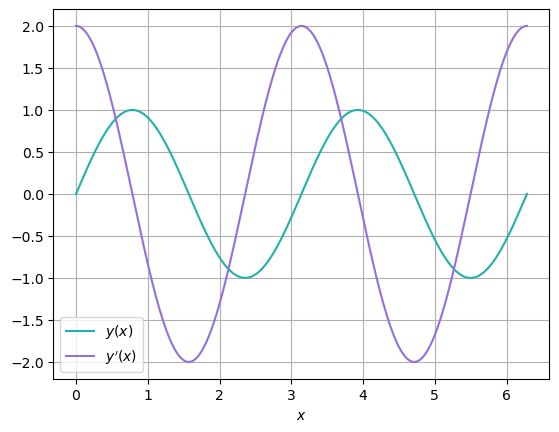

In [6]:
# Plotter y(x) og y'(x)
 
plt.plot(x_values, y_values, label = '$y(x)$', color = 'lightseagreen')
plt.plot(x_values, dy_values, label = "$y'(x)$", color = 'mediumpurple')
plt.xlabel('$x$')
plt.grid()
plt.legend()
plt.show()

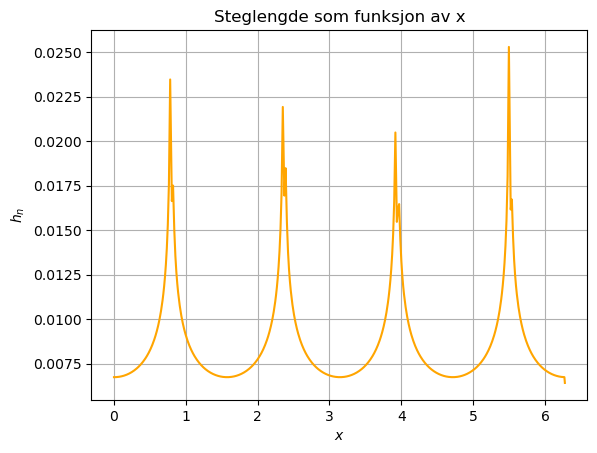

In [13]:
# Plotter steglengden som funksjon av x
plt.plot(x_values[:-1], step_array, color = 'orange')
plt.title('Steglengde som funksjon av x')
plt.xlabel('$x$')
plt.ylabel('$h_n$')
plt.grid()
plt.show() 

KOM MED TOLKNING HER!

Steglengden har makspunkter der y(x) har ekstremalpunkter.
Steglengden har minimumdpunkter der y(x) har vendepunkter.

SAMMENLIGN MED DEN DERIVERTE! Lite endring per x gir store steglengder!
